# Codici di Hamming: geometria, costruzione e simulazioni su BSC
Samuele Villa 84740A

# Introduzione

Nel modello classico della teoria dell’informazione (Shannon 1948), la comunicazione è descritta come una catena composta da:

<img src="figures/diagramma_comunicazioni.svg" width="100%">

Ogni sistema di comunicazione reale è soggetto a rumore. Che si tratti di trasmissione su cavo, onde radio o memoria digitale il segnale trasmesso può essere alterato durante la propagazione. Anche un singolo errore di bit può compromettere l’integrità dell’informazione.

Per rendere affidabile la trasmissione su un canale rumoroso non è sufficiente inviare il messaggio così com’è. È necessario introdurre una trasformazione strutturata dell’informazione che consenta di rilevare e correggere eventuali errori. Tali trasformazioni vengono gestite da un **encoder** e un **decoder**. 

Considereremo messaggi binari $m \in \{0, 1\}^k$. L'encoder è una funzione
$$
 f : \{0, 1\}^k \rightarrow \{0, 1\}^n
$$ 

che associa a ogni messaggio una parola binaria di lunghezza n. 

Il decoder è una funzione 
$$
 g : \{0, 1\}^n \rightarrow \{0, 1\}^k
$$ 

che ha l'obiettivo di ricostruire il messaggio originale.

## Modello di canale

Consideriamo un canale rumoroso che introduce errori di tipo **bit flip**.

Se Alice invia la sequenza

$$
a = (a_1, ... , a_n)
$$

Bob riceve la sequenza

$$
b = (b_1, ... , b_n)
$$

dove per ogni indice esiste una probabilità di errore:

$$
p_e = P(b_i \not= a_i)
$$

Assumiamo dunque:
- errori indipendenti.
- nessuna perdita o aggiunta di bit.
- $p_e << \frac{1}{2}$

## Ridondanza

Lavoriamo negli spazi binari $\mathbb{F}_2^k$ e $\mathbb{F}_2^n$, dove $\mathbb{F}_2 = \{0,1\}$ è il campo binario con somma modulo 2, equivalente all'operatore XOR.


Per rendere possibile la correzione degli errori, l’encoder non si limita a trasmettere il messaggio originale, ma lo **immerge in uno spazio di dimensione maggiore**, introducendo informazione ridondante in modo strutturato.

Sia $\{0, 1\}^k$ l’insieme dei messaggi possibili. L'encoder è una funzione che associa a ciascun messaggio una parola binaria in $\{0, 1\}^n$ (con $n > k$) detta **codeword**.  

L’insieme delle codeword forma il **codice**:

$$
C := f(X) \subseteq \{0,1\}^n
$$

Il codice è un sottoinsieme proprio dello spazio binario totale. Non tutte le parole di lunghezza $n$ sono ammesse: solo quelle che soddisfano determinati vincoli. 

Questa restrizione introduce ridondanza: rispetto ai $n$ bit trasmessi, solo $k$ bit rappresentano informazione utile. Il **rate** del codice è definito come

$$
R = \frac{k}{n}
$$

e misura l’efficienza della codifica.

L’aggiunta di ridondanza comporta quindi un compromesso tra efficienza e robustezza rispetto agli errori del canale.

---

# Geometria dello spazio binario

## Distanza di Hamming

La scelta di considerare solo un sottospazio composto da alcuni elementi validi può essere meglio intuita con un argomento geometrico. Si possono infatti immaginare gli elementi di $\{0, 1\}^n$ come i vertici di un ipercubo n-dimensionale. In questo spazio la distanza naturale è la **distanza di Hamming**, definita come il numero di coordinate in cui due parole binarie differiscono:

$$
d(x, y) = |\{i \in \{1, ..., n\} | x_i \not= y_i \}|
$$

Geometricamente corrisponde alla distanza tra i vertici nel grafo dell'ipercubo. Gli errori di trasmissione corrispondono a spostamenti in questo spazio, e la correzione consiste nel ricondurre la parola ricevuta alla codeword più vicina.

<img src="figures/hypercubes.png" width="100%">

La distanza di Hamming è una **metrica**, cioè soddisfa:

1. $d(x,y) \ge 0$ e $d(x,y)=0$ se e solo se $x=y$;
2. $d(x,y)=d(y,x)$;
3. $d(u,v) \le d(u,w) + d(w,v);$  (disuguaglianza triangolare)

Sia $C \subseteq \{0,1\}^n$ un codice, definiamo la **distanza minima** del codice come

$$
d_{\min}(C) := \min\{ d(x,y) : x,y \in C,\ x \neq y \}.
$$

Essa misura quanto le codeword sono "separate" nello spazio binario.

Per $t \in \mathbb{N}$, definiamo la **sfera di Hamming** di raggio $t$ centrata in $x \in C$:

$$
B_t(x) := \{ z \in \{0,1\}^n : d(x,z) \le t \}.
$$

Geometricamente, $B_t(x)$ rappresenta l'insieme delle parole ottenibili da $x$ mediante al più $t$ bit flip.

## Condizione di correttezza

Si dimostra ora la correttezza di codici di correzione sotto l'ipotesi che il numero di errori sia $ \le t$.
### Lemma 
(Intersezione delle sfere $\Leftrightarrow$ centri vicini)

Se

$$
B_t(x) \cap B_t(y) \neq \varnothing,
$$

allora

$$
d(x,y) \le 2t.
$$

E viceversa. (Dimostrazione in appendice)

### Teorema

(Sfere di raggio $t$ disgiunte $\Leftrightarrow$ $d_{\min} \ge 2t+ 1$)

Le seguenti affermazioni sono equivalenti:

1. Le sfere di raggio $t$ centrate nelle codeword sono a due a due disgiunte:
   $$
   B_t(c) \cap B_t(c') = \varnothing
   \qquad \forall c \neq c' \in C.
   $$

2. La distanza minima del codice soddisfa:
   $$
   d_{\min}(C) \ge 2t+1.
   $$

**Dimostrazione.**

**(1 $\Rightarrow$ 2)**  
Supponiamo per assurdo che $d_{\min}(C) \le 2t$.  
Allora esistono $x \neq y \in C$ tali che $d(x,y) \le 2t$.  

Per il Lemma segue che  
$$
B_t(x) \cap B_t(y) \neq \varnothing,
$$
in contraddizione con (1).  

Quindi deve valere $d_{\min}(C) \ge 2t+1$.

**(2 $\Rightarrow$ 1)**  
Supponiamo per assurdo che esistano $x \neq y \in C$ con  
$$
B_t(x) \cap B_t(y) \neq \varnothing.
$$

Per il Lemma segue $d(x,y) \le 2t$,  
quindi $d_{\min}(C) \le 2t$, in contraddizione con (2).  

Dunque le sfere sono disgiunte.

QED.


### Corollario: Correzione univoca fino a $t$ errori

Se

$$
d_{\min}(C) \ge 2t+1,
$$

allora per ogni $c \in C$ e per ogni parola ricevuta $r \in \{0,1\}^n$ tale che

$$
d(r,c) \le t,
$$

si ha che 

> $r$ **appartiene a una e una sola** sfera $B_t(c)$.

Un decoder **corregge correttamente al più $t$ bit flip**.


### Hamming bound

Se il codice corregge fino a $t$ errori, allora le sfere di Hamming di raggio $t$ attorno alle codeword sono disgiunte:

$$
B_t(c) \cap B_t(c') = \varnothing
\qquad \text{per } c \neq c'.
$$

Ciascuna sfera contiene esattamente

$$
|B_t(c)| = \sum_{i=0}^{t} \binom{n}{i}
$$

parole, poiché si ottiene scegliendo $i$ posizioni (con $0 \le i \le t$) da modificare tra le $n$ disponibili.

Poiché tutte queste sfere sono contenute nello spazio totale $\{0,1\}^n$, che ha cardinalità $2^n$, si ottiene

$$
|C| \cdot |B_t(c)| \le 2^n.
$$

> Un codice che realizza l’uguaglianza si dice **perfetto**.

In tal caso le sfere di raggio $t$ attorno alle codeword ricoprono esattamente tutto lo spazio $\{0,1\}^n$.

Se $t=1$, la cardinalità della sfera è $1+n$, e l’uguaglianza diventa

$$
|C|(1+n) = 2^n.
$$

---

# Codice di Hamming

## Definizione


L’idea alla base dei codici di Hamming è l’uso sistematico di bit di **parità**.

Un bit di parità $p_I$ associato a un insieme di bit $\{b_{j}\}$ è un bit aggiuntivo scelto in modo che

$$
\bigoplus_{j \in I} b_j \oplus p_I = 0
$$

ossia che la somma modulo 2 dei bit controllati sia nulla.

Un singolo bit di parità consente di rilevare un errore, ma non di identificarne la posizione.  


I codici di Hamming sono famiglie di codici $(n, k)$, dove $n = 2^r - 1$ rappresenta il numero totale di bit inviato e $k = 2^r - 1 - r$ rappresenta il numero di bit informativi, per ogni intero $r \ge 2$. L’idea di Hamming è introdurre più bit di parità in modo strutturato, così da poter localizzare un errore singolo.

Le posizioni riservate ai bit di parità sono le potenze di due. La ragione di questa scelta è legata alla rappresentazione binaria degli indici. Le potenze di due infatti hanno la proprietà di avere una rappresentazione binaria che contiene un solo 1:

$$
\begin{aligned}
1  &= (00\dots001)_2 \\
2  &= (00\dots010)_2 \\
4  &= (00\dots100)_2 \\
8  &= (00\dots1000)_2 \\
&\ \vdots
\end{aligned}
$$

Ogni posizione $i \in \{1,\dots,2^r-1\}$ può essere identificata dalla sua rappresentazione binaria su $r$ bit:

$$
i = (i_{r-1} i_{r-2} \dots i_0)_2.
$$

Ciascun bit di parità controlla una "colonna" di questa rappresentazione:

- Il primo bit di parità controlla tutte le posizioni il cui indice ha 1 nella prima cifra.
- Il secondo bit di parità controlla tutte le posizioni il cui indice ha 1 nella seconda cifra.
- E così via.

Il numero 5 ad esempio è controllato dai bit di parità posizionati di indice 1 e 4, questo perchè la rappresentazione binaria di 5 è $101_2$.

In altre parole, ogni posizione $i$ è controllata esattamente dai bit di parità corrispondenti alle cifre 1 della sua rappresentazione binaria.

### Sindrome

Data una parola ricevuta $b = (b_1, \dots, b_n)$, definiamo la **sindrome** come il vettore

$$
s = (s_{r-1}, \dots,s_0),
$$

$$
s_j =
\begin{cases}
1 & \text{se la $j$-esima condizione di parità non è soddisfatta} \\
0 & \text{se la $j$-esima condizione di parità è soddisfatta}
\end{cases}
$$

Se non si è verificato alcun errore, tutte le condizioni di parità restano soddisfatte e quindi

$$
s=(0,\dots,0).
$$

Supponiamo ora che un singolo bit in posizione $i$ venga invertito:

- ogni controllo di parità associato a una cifra 1 dell’indice $i$ fallisce;
- ogni controllo di parità associato a una cifra 0 dell'indice $i$ resta corretto.

Il vettore dei controlli falliti è quindi

$$
s = (i_{r-1} \dots i_0)_2,
$$

cioè coincide esattamente con la rappresentazione binaria della posizione in cui si è verificato l’errore.

Un metodo equivalente ed elegante di interpretare il calcolo della sindrome si ottiene sommando con modulo 2 le posizioni dei bit del messaggio che contengono un 1. In questo modo con una semplice somma su $r$ bit si ottiene la posizione dell'errore.

## Descrizione matriciale

Per formalizzare la costruzione dei codici di Hamming introduciamo il punto di vista lineare.

### Matrice di controllo $H$

Il codice di Hamming può essere descritto tramite una matrice detta **matrice di controllo**

$$
H \in \mathbb{F}_2^{r \times n}.
$$

Una parola $c \in \mathbb{F}_2^n$ è una codeword se e solo se

$$
H c^T = 0.
$$

In cui:

- ogni riga di $H$ rappresenta un vincolo di parità;
- il prodotto riga-vettore calcola la somma modulo 2 (XOR) dei bit selezionati;
- l’equazione $Hc^T = 0$ significa che tutte le condizioni di parità sono soddisfatte.

La matrice $H$ si costruisce prendendo come colonne tutti i vettori binari non nulli di lunghezza $r$, ciascuno una sola volta. Equivalentemente:

> l'$i$-esima colonna di $H$ è la rappresentazione binaria del numero $i$ su $r$ bit.

Ad esempio, per $r=3$ (quindi $n=7$):

$$
H =
\begin{pmatrix}
1 & 0 & 1 & 0 & 1 & 0 & 1 \\
0 & 1 & 1 & 0 & 0 & 1 & 1 \\
0 & 0 & 0 & 1 & 1 & 1 & 1
\end{pmatrix}.
$$

Le colonne corrispondono agli indici

$$
1=(001)_2,\;
2=(010)_2,\;
3=(011)_2,\;
4=(100)_2,\;
5=(101)_2,\;
6=(110)_2,\;
7=(111)_2.
$$

In questo modo la descrizione matriciale coincide esattamente con la costruzione combinatoria vista in precedenza.

Nel paragrafo precedente abbiamo definito la sindrome come il vettore dei controlli di parità falliti. La descrizione matriciale compatta questa stessa operazione nel prodotto

$$
s = H r^T.
$$
### Localizzazione di un errore singolo

Supponiamo che si sia verificato un solo errore in posizione $i$. Il modello di canale diventa quindi

$$
r = c + e,
$$

dove $e$ è un vettore di soli zeri, tranne per l'$i$-esima cifra dove si introduce l'errore. In questo caso

$$
s = H r^T = H (c + e)^T = 0 + H e^T = He^T
$$

coincide esattamente con la colonna $i$ di $H$.

Ma le colonne di $H$ sono tutte diverse e non nulle. Ne segue che:

- $s \neq 0$ indica la presenza di un errore singolo;
- il valore di $s$ coincide con la rappresentazione binaria dell’indice $i$;

È quindi possibile identificare univocamente la posizione dell’errore e correggerlo.

---

## Correttezza

Ribadiamo innanzitutto che $C$ è un codice lineare, essendo il nucleo dell'applicazione lineare $c \mapsto Hc^T$.  
Per i codici lineari vale quindi

$$
d_{\min}(C) = \min\{ d(x,y) : x,y \in C,\ x \neq y \} = \min\{ \mathrm{wt}(c) : c \in C,\ c \neq 0 \}.
$$

Mostriamo ora che $d_{\min}(C)=3$.

- Non può esistere una codeword di peso 1: infatti, se $c$ ha un solo 1 in posizione $i$, allora $Hc^T$ coincide con la colonna $i$ di $H$, che è non nulla.

- Non può esistere una codeword di peso 2: se $c$ ha 1 in posizioni $i$ e $j$, allora
  $$
  Hc^T = \text{colonna } i \oplus \text{colonna } j,
  $$
  che non può essere zero perché le colonne di $H$ sono tutte distinte.

- Esistono invece codeword di peso 3: infatti, date due colonne distinte $i$ e $j$, il loro XOR è un vettore binario non nullo, quindi coincide con una terza colonna $k$ di $H$. Ne segue
  $$
  \text{colonna } i \oplus \text{colonna } j \oplus \text{colonna } k = 0,
  $$
  e dunque il vettore con 1 nelle posizioni $i,j,k$ è una codeword.

Concludiamo che

$$
d_{\min}(C) = 3.
$$

Dal teorema generale visto in precedenza, un codice con distanza minima $3$ corregge l'errore.  

Si ripete e si sottolinea che tale conclusione vale soltanto nel caso di **errore singolo**: se si verificano due o più errori, la sindrome è la somma (modulo 2) delle colonne corrispondenti e il decoder progettato per errori singoli può produrre una correzione errata. Un codice di questo tipo è detto SEC(single error correction).

---

## Codice di Hamming esteso (SECDED)

Il codice di Hamming può essere modificato aggiungendo un **bit di parità globale** alla parola codificata.  
Se il codice standard ha parametri

$$
(n,k) = (2^r - 1,\; 2^r - r - 1),
$$

il codice esteso ha invece

$$
(n',k) = (2^r,\; 2^r - r - 1).
$$

Il nuovo bit viene scelto in modo che la parità complessiva della parola sia pari, cioè

$$
\bigoplus_{i=1}^{n'} c_i = 0.
$$

In questo modo tutte le codeword hanno **peso pari**.
Nel codice esteso la distanza minima diventa

$$
d_{\min}=4.
$$

La ragione è semplice: il codice è lineare e, imponendo la parità globale, non possono esistere codeword di peso dispari.

 In particolare non possono esistere codeword di peso $3$. Poiché esistono codeword di peso $4$, il minimo peso non nullo è $4$, e quindi la distanza minima è $4$.

Dal criterio generale $2t+1 \le d_{\min}$ segue che il codice esteso:

- corregge ancora un errore singolo ($t=1$);
- rileva fino a due errori (sindrome non nulla ma parità corretta).

Per questo motivo è spesso indicato come codice **SECDED** (*Single Error Correction, Double Error Detection*).

---

## Costo in spazio

Uno specifico codice di Hamming è identificato dai parametri $(n,k)$:

- $k$: numero di bit **informativi** (messaggio),
- $n$: numero di bit **trasmessi** (codeword),
- $r = n-k$: numero di bit di **parità** (ridondanza).

Per il codice di Hamming (binario) con parametro $r \ge 2$ si ha:

$$
n = 2^r - 1,
\qquad
k = 2^r - r - 1,
\qquad
n-k = r.
$$

Quindi il rate del codice è:

$$
R = \frac{2^r - r - 1}{2^r - 1} = 1 - \frac{r}{2^r - 1}
$$


| r | n = 2^r − 1 | k = 2^r − r − 1 | Bit di parità (r) | Rate R = k/n |
|:--:|:-----------:|:---------------:|:------------------:|:------------:|
| 2 | 3   | 1   | 2 | 0.33 |
| 3 | 7   | 4   | 3 | 0.57 |
| 4 | 15  | 11  | 4 | 0.73 |
| 5 | 31  | 26  | 5 | 0.84 |
| 6 | 63  | 57  | 6 | 0.90 |
| 7 | 127 | 120 | 7 | 0.94 |

Al crescere di $r$ il rate $R$ tende a $1$; parallelamente l’aumento della lunghezza del blocco comporta una maggiore probabilità di errori multipli.

Dal Hamming bound, ogni codice che corregge un errore singolo deve soddisfare

$$
|C|(1+n) \le 2^n.
$$

Nel caso del codice di Hamming vale

$$
|C| = 2^k.
$$

Sostituendo le espressioni di sopra per $n$ e $k$ si ottiene l’uguaglianza, quindi il bound è saturo e il codice è **perfetto**.

<img src="figures/3b1b_hamming.png" width="100%">

È importante osservare che, a differenza del codice di Hamming standard, il codice esteso non è più perfetto: l’aggiunta del bit di parità globale aumenta la distanza minima ma rompe l’uguaglianza dell'Hamming bound. Infatti ora $n = 2^r$ e con semplici calcoli algebrici si giunge a

$$
2^{k-n} \leq 1.
$$

Dal momento che $k < n$ non si può ottenere l'uguaglianza.

---

## Costo in tempo

In questa trattazione viene separato l'algoritmo nella codifica e nella decodifica. Verrà scritto lo pseudocodice di entrambe le fasi e analizzati i rispettivi costi in tempo considerando le operazioni elementari a livello di singolo bit.

### Codifica

L'algoritmo di codifica prende in input $k$ bit informativi e il numero di bit di parità $r$, e genera un blocco di lunghezza $n$ che rispetta i parity check da inviare.

```text
Algorithm EncodeHamming(m, r)

Input:
    m[1..k]  vettore dei bit informativi
    r        numero di bit di parità

Output:
    c[1..n]  codeword di lunghezza n = 2^r − 1


// 1. Calcolo della lunghezza totale, alloco il vettore della codeword
n ← 2^r − 1
allocate array c[1..n] initialized to 0

// 2. Inserisco i bit informativi
// Le posizioni che NON sono potenze di 2 contengono dati
j ← 1  // Indice dei bit informativi
for i from 1 to n do
    if (i AND (i-1)) != 0 do
        c[i] ← m[j]
        j ← j + 1

// 3. Calcolo i bit di parità
// Ogni bit di parità si trova in posizione 2^t
for t from 0 to r−1 do
    p ← 2^t
    parity ← 0

    // Scorro tutte le posizioni della parola
    for i from 1 to n do
        // Controllo se il bit t-esimo della rappresentazione binaria di i è 1
        if (i AND p) != 0 do
            parity ← parity XOR c[i]

    c[p] ← parity

return c
```
Analizziamo il costo dell’algoritmo `EncodeHamming(m,r)` scomponendolo in fasi.  
Assumiamo che le seguenti operazioni abbiano costo **costante** (indipendente da $n$ e $r$):

- assegnamenti e accessi a celle di array;
- operazioni booleane/bitwise (XOR, AND);
- confronti e salti condizionali;

Indichiamo con $c_a, c_b, c_c$ costanti positive che rappresentano tali costi elementari (rispettivamente operazioni aritmetiche/assegnamenti, test/logiche, aggiornamenti con accesso a memoria).

**Fase 1: calcolo di $n$ e allocazione**

Operazioni:

- calcolo $n \leftarrow 2^r - 1$ → costo $c_a$.
- allocazione e inizializzazione di un array di lunghezza $n$ → costo $n c_a$.

Costo in tempo:

$$
T_1(n) = c_a + c_a n = \Theta\!\big( n\big).
$$

**Fase 2: inserimento dei bit informativi**

Il ciclo scorre tutte le posizioni $i = 1,\dots,n$, e per ogni $i$: 
- esegue un test “$i$ non è potenza di 2”, implementabile con $(i \&  (i-1)) \neq 0,$ → costo $c_b$.
- se la condizione è vera, assegna un bit informativo e incrementa $j$ → costo $c_a$.

Il ramo “vero” avviene esattamente $k$ volte, dove $k = n - r.$ Il costo in tempo è dunque:

$$
T_2(n,r) = c_b \, n + c_a \, k
         = c_b \, n + c_a (n-r) = \Theta\!\big(n\big).
$$


**Fase 3: calcolo dei bit di parità (DOMINANTE)**

Il ciclo esterno scorre $t = 0,\dots,r-1$ quindi $r$ iterazioni. Per ogni $t$:

- calcolo $p \leftarrow 2^t$ → costo $c_a$;
- inizializzazione `parity ← 0` → costo $c_a$;
- ciclo interno su $i = 1,\dots,n$:
  - test $(i \ \&\ p) \neq 0$ → costo $c_b$;
  - se vero, aggiorna `parity ← parity XOR c[i]` → costo $c_c$.
  
Su $1,\dots,2^r-1$ ogni bit non nullo compare con frequenza $2^{r-1}$, quindi il ramo “vero” è eseguito esattamente $2^{r-1}$ volte, cioè

$$
2^{r-1} = \frac{n+1}{2}.
$$

Quindi, per un $t$ fissato, il costo del ciclo interno è:

$$
c_b \, n \;+\; c_c  \frac{n+1}{2}.
$$

Infine l’assegnamento $c[p] \leftarrow parity$ costa $c_{a}$.

Costo per un singolo $t$:

$$
T_{3,\text{per }t}(n) = 2 c_a + c_b n + c_c \frac{n+1}{2} = \Theta\!\big(n\big).
$$

Ricordando $t = 0,\dots,r-1$, moltiplichiamo per $r = \log_2(n-1)$:

$$
T_3(n,r) = \log_2(n-1)\left(2 c_a + c_b n + c_c \frac{n+1}{2}\right) = \Theta\!\big(n \log n\big).
$$


**Costo totale**

Sommando le tre fasi, otteniamo che l'algoritmo di codifica di Hamming standard richiede tempo:

$$
T(n) = T_1(n) + T_2(n) + T_3(n) = \Theta\!\big(n \log n\big).
$$


In particolare, il costo è dominato dal calcolo dei bit di parità, che esegue $r$ scansioni complete della parola di lunghezza $n$.

---

### Decodifica

L'algoritmo di decodifica prende in input una parola ricevuta $r[1, \dots, n]$ e restitiuisce la parola corretta, assumendo che si sia verificato **al più un errore**.

L'idea è la seguente:

- calcolare la sindrome $s=Hr^T$.
- se $s=0$, non si corregge nulla.
- se $s\neq0$, il valore binario della sindrome identifica la posizione dell'errore, dunque correggere il bit in quella posizione.
- estrarre i bit informativi corretti.

```text
Algorithm DecodeHamming(r, r_parity)

Input:
    r[1, ..., n]        parola ricevuta
    r_parity       numero di bit di parità

Output:
    parola corretta

// 1. Calcolo della sindrome
allocate array s[0, ..., r_parity−1] initialized to 0

for t from 0 to r_parity−1 do
    p ← 2^t
    parity ← 0

    for i from 1 to n do
        if (i AND p) != 0 then
            parity ← parity XOR r[i]

    s[t] ← parity


// 2. Ricostruzione dell'indice dell'errore e correzione
error_position ← 0

for t from 0 to r_parity−1 do
    if s[t] = 1 then
        error_position ← error_position + 2^t


// Correzione
if error_position != 0 then
    r[error_position] ← r[error_position] XOR 1

// 3. Estrazione bit informativi
allocate array m[1, ..., k]
j = 1

for i from 1 to n do
    if (i AND (i-1)) != 0
        m[j] ← r [i]
        j++

return m
```

Analizziamo il costo dell'algoritmo `DecodeHamming(r, r_parity)` scomponendolo in fasi:

**Fase 1: calcolo della sindrome (DOMINANTE)**

Viene innanzitutto allocata e inizializzata la sindrome, un array di lunghezza $r$ → costo $\log_2(n) c_a$.


Il ciclo esterno scorre $t = 0,\dots,r-1$, quindi effettua $r = \log_2(n)$ iterazioni.

Per ogni $t$:

- calcolo $p \leftarrow 2^t$ → costo $c_a$;
- inizializzo `parity ← 0` → costo $c_a$;
- ciclo interno su $i = 1,\dots,n$:
    - test `(i AND p) != 0` → costo $c_b$;
    - se vero, aggiorno `parity ← parity XOR r[i]` → costo $c_c$;
- assegnamento `s[t] ← parity` → costo $c_a$.

Come nel caso della codifica, per un valore fissato di $t$ il ramo vero viene eseguito esattamente $2^{r-1} = \frac{n+1}{2}$ volte. Il costo complessivo a $t$ fissato è:

$$
T_{1, t fissato} (n) = \log_2(n)c_a + 3 c_a + n c_b + \frac{n+1}{2} c_c = \Theta \big(n\big)
$$

Esattamente come prima, $t$ va da $0$ fino a $r-1$ per cui moltiplichiamo il tutto per $r = \log_2(n-1)$. In questo modo otteniamo il costo in tempo del calcolo della sindrome:

$$
T_1(n) = \log_2(n-1) \big(\log_2(n)c_a + 3 c_a + n c_b + \frac{n+1}{2} c_c \big)= \Theta \big(n \log n\big)
$$


**Fase 2: ricostruzione dell'indice dall'errore e correzione del bit**

Il ciclo scorre da $t = 0, \dots, r-1$, e per ogni $t$:
- test $s[t] = 1$ → costo $c_b$;
- eventuale aggiornamento `error_position ← error_position + 2^t` → costo $c_a$.

A cui aggiungiamo i costi singoli di:
- test `error_position != 0` → costo $c_b$;
- eventuale bitflip correttivo `r[error_position] ← r[error_position] XOR 1` → costo $c_c$.

Il costo in tempo della seconda fase è dunque:

$$
T_2(n) = \log_2(n-1)(c_b + c_a) + c_b + c_c = \Theta \big(\log n\big)
$$

**Fase 3: estrazione dei bit informativi**

Dopo aver allocato un vettore di lunghezza $k = n - r$ viene fatta una scansione sugli $n$ elementi e un assegnazione di $k$ elementi:

$$
T_3(n) = 2(n-r)c_a + n c_b = \Theta \big(n \big)
$$

**Costo totale della decodifica**

Sommando le due fasi otteniamo il costo totale:

$$
T(n) = T_1(n) + T_2(n) + T_3(n) = \Theta \big(n \log n \big)
$$

Quindi la decodifica ha lo stesso ordine asintotico della codifica, e in questo caso il calcolo della sindrome è il termine dominante.

Il costo sulle macchine moderne (ad esempio a 64bit) si può ridurre $\Theta (n)$ in quanto le operazioni come la somma di numeri binari di lunghezza $r$ è costante e non va come $\log_2(n)$.

---

# Implementazione e test

In questa sezione verranno implementati i codici di codifica e decodifica di Hamming. Questa implementazione verrà poi testata su messaggi reali e su un'immagine.

### Funzioni e algoritmo

Si comincia definendo alcune funzioni utili alla costruzione degli algoritmi di Hamming.

In [ ]:
#Somma modulo 2 (XOR) di una lista di bit 0/1.
def xor_sum(bits):
    s = 0
    for b in bits:
        s ^= b
    return s

#Il numero è una potenza di due?
def is_power_of_two(x):
    return x > 0 and (x & (x - 1)) == 0

#Calcola la sindrome, dunque la posizion dell'erore, come intero per Hamming standard.
def syndrome_hamming(codeword, r):

    # Ricostruisco vettore indicizzato 1..n
    n = len(codeword)
    c = codeword[:]

    s = 0
    for t in range(r):
        p = 2**t
        parity = 0
        for i in range(n):
            if ((i+1) & p) != 0: # La parità va calcolata sui bit che hanno 1 nell'indice nella posizione di interesse per ciascuna t.
                parity ^= c[i]
        if parity == 1:
            s += p # Costruisce l'intero che corrisponde alla posizione dell'errore.
    return s

Si prosegue implementando gli algoritmi di codifica e decodifica di Hamming standard.

In [ ]:
# Codifica di Hamming standard
def encode_hamming(data_bits, r):

    n = 2**r - 1
    k = n - r
    # Se il numero di bit non corrisponde a quello atteso -> messaggio di errore
    assert len(data_bits) == k, f"Atteso k={k} bit, ricevuti {len(data_bits)}"

    # 1) inserisco i dati nelle posizioni non potenze di 2
    c = [0] * n
    j = 0
    for i in range(n):
        if not is_power_of_two(i+1): # i+1 perchè python parte da 0
            c[i] = data_bits[j]
            j += 1

    # 2) calcolo i bit di parità (posizioni 2^t)
    for t in range(r):
        p = 2**t
        parity = 0
        for i in range(n):
            # Vanno controllati i bit il cui indice ha un 1 nella stessa posizione di 2**t
            if ((i+1) & p) != 0:
                parity = parity ^ c[i]
        c[p-1] = parity

    return c


# Decodifica di Hamming standard
def decode_hamming(codeword, r):
  
    n = len(codeword)
    c = codeword[:]

    s = syndrome_hamming(codeword, r)
    corrected = False
    if s != 0 and 1 <= s <= n: # Controllo che s sia non nullo e sensato
        c[s-1] = c[s-1] ^ 1 # Flippa il bit nella posizione indicata dalla sindrome, s-1 sempre per il base(0) di python
        corrected = True

    # Estraggo i bit informativi
    data = []
    for i in range(n):
        if not is_power_of_two(i+1):
            data.append(c[i])

    return c, data, corrected

### Esempio 1: testo

Vengono ora implementate le funzioni che gestiscono la conversione del testo in bit e viceversa, e le funzioni che simulano il canale rumoroso.

Verrà usato il modello BSC (Binary Simmetric Channel), un modello di canale fondamentale in teoria dell'informazione in cui i bit hanno probabilità $p$ di cambiare il loro stato. 

In [ ]:
# Converte testo in bit
def text_to_bits(text):
    bits = []
    for ch in text:
        b = format(ord(ch), "08b")
        bits.extend(int(x) for x in b)
    return bits

# Converte bit in testo
def bits_to_text(bits):
    chars = []
    # tronco a multipli di 8
    L = (len(bits) // 8) * 8
    for i in range(0, L, 8):
        byte = bits[i:i+8]
        val = int("".join(str(x) for x in byte), 2)
        chars.append(chr(val))
    return "".join(chars)

# Padding con zeri per avere multipli di size
def pad_bits(bits, size):
    
    rem = len(bits) % size
    if rem == 0:
        return bits[:], 0
    pad = size - rem
    return bits + [0]*pad, pad

# Spezza i dati in chunks delle dimensioni desiderate
def chunk(bits, size):
    return [bits[i:i+size] for i in range(0, len(bits), size)]


import random

# Ogni bit viene flippato con probabilità p
def bsc_channel(bits, p):
    out = bits[:]
    flips = 0
    for i in range(len(out)):
        if random.random() < p:
            out[i] ^= 1
            flips +=1
    return out, flips

Viene simulata la trasmissione del messaggio *"Luck favors the prepared mind"* su un canale BSC con diverse probabilità di bit-flip $p$. Per ciascun valore di $p$ vengono poi eseguite 1000 trasmissioni indipendenti e si riportano i risultati medi.

Per ogni $p$ la tabella mostra:

- la frazione media di codeword con $0, 1$ o $\ge 2$ errori osservata in simulazione.
- il corrispondente valore teorico atteso, calcolato con la distribuzione binomiale.
- la frazione media di blocchi su cui il decoder ha applicato una correzione.
- un esempio di testo decodificato, solo a scopo illustrativo, confrontato con la trasmissione senza codici di Hamming.

In [ ]:
# Simulazione di trasmissione testo, restituisce il testo ricevuto e decodificato, la percentuale di blocchi corretti, quante volte sono avvenuti 0, 1, 2 o più di 2 flip per blocco
def transmit_text_hamming(text, r, p):
    n = 2**r - 1
    k = n - r

    bits = text_to_bits(text)
    bits_padded, pad = pad_bits(bits, k)
    blocks = chunk(bits_padded, k)

    # encode -> channel -> decode
    corrected_count = 0   # Conto quante correzioni sono state fatte
    decoded_bits = []
    flips_count = []
    for blk in blocks:
        cw = encode_hamming(blk, r)       
        cw_noisy, flips = bsc_channel(cw, p)        
        cw_corr, data, corrected = decode_hamming(cw_noisy, r)
        if corrected:
            corrected_count += 1 
        decoded_bits.extend(data)
        flips_count.append(flips)

    # rimuovo padding e torno a testo
    if pad:
        decoded_bits = decoded_bits[:-pad]
    
    zero_flips = flips_count.count(0)
    one_flip = flips_count.count(1)
    more_flips = len(flips_count) - zero_flips - one_flip

    return bits_to_text(decoded_bits), (corrected_count/len(blocks)), zero_flips, one_flip, more_flips

# Contatore di errori sui caratteri
def char_error_rate(original, received):
    L = len(received)
    diff = sum(1 for i in range(L) if original[i] != received[i])

    return diff / L

# Trasmissione senza correzione. Restituisce (text_noisy, num_bits).
def transmit_text_plain(text, p):
    
    bits = text_to_bits(text)
    noisy_bits, _ = bsc_channel(bits, p)   # assume che bsc_channel funzioni su liste di bit
    return bits_to_text(noisy_bits), len(bits)

#TABELLA RISULTATI HAMMING NORMALE

import pandas as pd
import math

prob = [0.01, 0.025, 0.05, 0.1]
text = "Luck favors the prepared mind"
r = 4
n = 2**r - 1
trials = 1000

rows = []

for p in prob:

    sum_zero = sum_one = sum_two = sum_more = sum_cer = sum_cer_plain = 0
    sum_corrected = 0
    example_text, _, _, _, _ = transmit_text_hamming(text, r, p)
    example_text_plain, _ = transmit_text_plain(text, p)

    for _ in range(trials):
        out, corrected_count, zero, one, more = transmit_text_hamming(text, r, p)
        cer = char_error_rate(text, out)
        sum_cer += cer

        out_plain, _ = transmit_text_plain(text, p)
        cer_plain = char_error_rate(text, out_plain)
        sum_cer_plain += cer_plain

        sum_zero += zero
        sum_one += one
        sum_more += more
        sum_corrected += corrected_count

    total_blocks = sum_zero + sum_one + sum_more

    # Probabilità simulate (media Monte Carlo)
    P0_sim = sum_zero / total_blocks
    P1_sim = sum_one / total_blocks
    Pm_sim = sum_more / total_blocks

    # Probabilità teoriche (BSC + Hamming), Binomiale
    P0_th = (1-p)**n
    P1_th = n*p*(1-p)**(n-1)
    Pm_th = 1 - P0_th - P1_th

    rows.append({
        "p": p,
        "P0_sim": P0_sim,
        "P0_theory": P0_th,
        "P1_sim": P1_sim,
        "P1_theory": P1_th,
        "P>=2_sim": Pm_sim,
        "P>=2_theory": Pm_th,
        "correction_rate": sum_corrected / trials,
        "Char_error_rate": sum_cer / trials,

        "example_text": example_text,

        "Char_error_rate_plain": sum_cer_plain / trials,
        "example_text_plain": example_text_plain
    })


df = pd.DataFrame(rows)
fmt = {col: "{:.3f}" for col in df.columns if col not in ("example_text", "example_text_plain")}
display(df.style.format(fmt))

,p,P0_sim,P0_theory,P1_sim,P1_theory,P>=2_sim,P>=2_theory,correction_rate,Char_error_rate,example_text,Char_error_rate_plain,example_text_plain
0,0.010,0.860,0.860,0.130,0.130,0.010,0.010,0.140,0.011,Luck favors the prepared mind,0.079,"Luck favors$the prepazed""minä"
1,0.025,0.687,0.684,0.262,0.263,0.052,0.053,0.313,0.058,Luck#favors the prepared mind,0.183,"\uck""favors ôhe prepared¢mKìd"
2,0.050,0.465,0.463,0.366,0.366,0.169,0.171,0.532,0.181,Luck favors&he prepared mind,0.332,Huck favoÒs vhe!pråparud mën$
3,0.100,0.211,0.206,0.341,0.343,0.449,0.451,0.775,0.470,ouck favmò7©&he qhezirqä «Izd,0.567,Muck fav/r7 thg0prepá0gd0oind


I risultati mostrano un eccellente accordo tra probabilità simulate e valori teorici, confermando la corretta implementazione sia del canale BSC sia del codice di Hamming.

Si osserva inoltre che il tasso di correzione cresce con $p$, poiché aumentano anche i casi con singolo errore correggibile. Tuttavia, oltre una certa soglia, l’aumento degli errori multipli domina il comportamento del sistema e la qualità del messaggio decade rapidamente.

Il confronto con la trasmissione "plain" ovvero senza l'utilizzo dei codici di Hamming mostra la loro efficacia.

### Esempio 2: immagine

La stessa pipeline utilizzata per il testo viene ora applicata a un’immagine. Dopo la conversione in bit, i dati vengono codificati con Hamming, trasmessi su un canale rumoroso e infine decodificati pe rricostruire l'immagine.

Lo scopo di questa sezione è puramente illustrativo: mostrare visivamente l’effetto del rumore e il ruolo del codice di correzione nel limitare la degradazione dell’informazione.

In [ ]:
from PIL import Image

# Da bytes a bits
def bytes_to_bits(data: bytes):
    bits = []
    for b in data:
        for i in range(7, -1, -1):
            bits.append((b >> i) & 1)
    return bits

# Da bits a bytes
def bits_to_bytes(bits):
    if len(bits) % 8 != 0:
        raise ValueError("bits_to_bytes: numero di bit non multiplo di 8")
    out = bytearray()
    for i in range(0, len(bits), 8):
        x = 0
        for k in range(8):
            x = (x << 1) | (bits[i + k] & 1)
        out.append(x)
    return bytes(out)

# Da immagine a bits.
def image_to_bits(path, W, H):
  
    img = Image.open(path).convert("RGB").resize((W, H))
    pixel_bytes = img.tobytes()                
    return bytes_to_bits(pixel_bytes)

# Da bits a image.
def bits_to_image(bits, out_path, W, H):

    pixel_bytes = bits_to_bytes(bits)
    expected = W * H * 3
    if len(pixel_bytes) < expected:
        raise ValueError("Dati insufficienti per ricostruire l'immagine.")
    pixel_bytes = pixel_bytes[:expected]
    img = Image.frombytes("RGB", (W, H), pixel_bytes)
    img.save(out_path)
   

    

# Stessa pipeline della trasmissione di testo: image -> bits -> pad -> chunk(k) -> encode -> chunk(n) -> BSC -> decode -> unpad -> image
def transmit_image_hamming(image_path, out_path, r, p):
    n = 2**r - 1
    k = n - r

    bits = image_to_bits(image_path)
    bits_padded, pad = pad_bits(bits, k)
    blocks = chunk(bits_padded, k)

    # encode -> channel -> decode
    decoded_bits = []
    for blk in blocks:
        cw = encode_hamming(blk, r)          # lunghezza n

        cw_noisy = bsc_channel(cw, p)        # lunghezza n
        # se bsc_channel ritorna (noisy, flipped), prendo solo noisy
        if isinstance(cw_noisy, tuple):
            cw_noisy = cw_noisy[0]

        cw_corr, data, _ = decode_hamming(cw_noisy, r)
        decoded_bits.extend(data)            # k bit

    # rimuovo padding e torno a immagine
    if pad:
        decoded_bits = decoded_bits[:-pad]

    bits_to_image(decoded_bits, out_path)
    return out_path



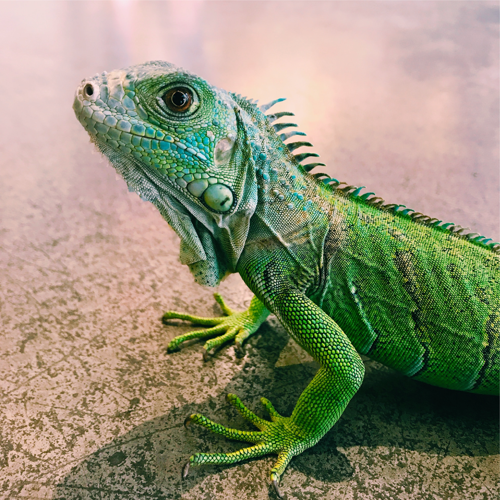

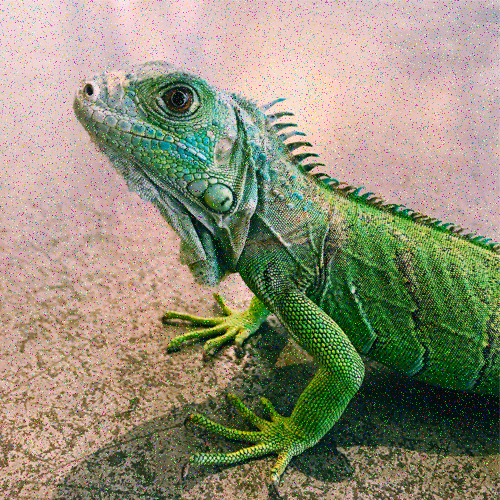

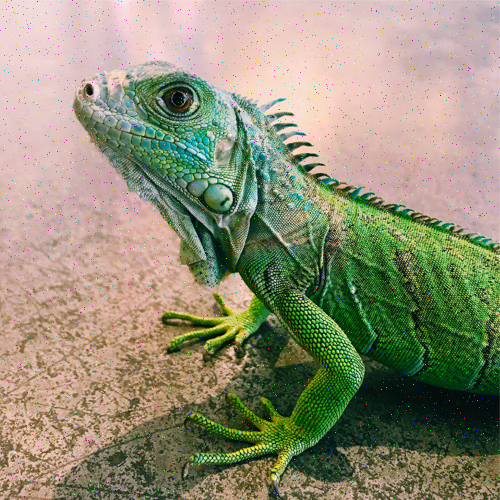

In [ ]:
from PIL import Image
from IPython.display import display

# Parametri immagine
in_path = "figures/charlie.png"
W, H = 500, 500 

# Parametri canale e Hamming
p = 0.025
r = 3           

# 1) Originale (ridimensionata per coerenza con W,H)
img0 = Image.open(in_path).convert("RGB").resize((W, H))
display(img0)

# 2) Noisy senza Hamming (solo BSC sui bit dei pixel)
bits = image_to_bits(in_path, W, H)
bits_noisy, _ = bsc_channel(bits, p)
bits_to_image(bits_noisy, "figures/charlie_noisy.png", W, H)
display(Image.open("figures/charlie_noisy.png"))

# 3) Noisy + corretto con Hamming
def transmit_image_hamming_fixed(in_path, out_path, W, H, r, p):
    n = 2**r - 1
    k = n - r

    bits = image_to_bits(in_path, W, H)
    bits_padded, pad = pad_bits(bits, k)
    blocks = chunk(bits_padded, k)

    decoded_bits = []
    for blk in blocks:
        cw = encode_hamming(blk, r)
        cw_noisy, _ = bsc_channel(cw, p)
        cw_corr, data, _ = decode_hamming(cw_noisy, r)
        decoded_bits.extend(data)

    if pad:
        decoded_bits = decoded_bits[:-pad]

    bits_to_image(decoded_bits, out_path, W, H)

transmit_image_hamming_fixed(in_path, "figures/charlie_corrected.png", W, H, r, p)
display(Image.open("figures/charlie_corrected.png"))

---

# Appendice

## Dimostrazione lemma

**Dimostrazione (Intersezione delle sfere $\Rightarrow$ centri vicini).**  
Se l’intersezione è non vuota, esiste $z$ tale che  $d(x,z) \le t$ e $d(y,z) \le t$.  

Per la disuguaglianza triangolare,

$$
d(x,y) \le d(x,z) + d(z,y) \le t + t = 2t.
$$

QED

**Dimostrazione (Centri vicini $\Rightarrow$ intersezione delle sfere)**  

Sia

$$
S := \{ i \in \{1,\dots,n\} : x_i \neq y_i \}.
$$

Allora

$$
|S| = d(x,y) =: d \le 2t.
$$

Scegliamo un sottoinsieme $T \subseteq S$ tale che

$$
|T| = \lfloor d/2 \rfloor.
$$

Definiamo $z \in \{0,1\}^n$ ponendo

- $z_i := y_i$ se $i \in T$,
- $z_i := x_i$ se $i \in S \setminus T$.

Allora $z$ differisce da $x$ esattamente sulle coordinate in $T$, quindi

$$
d(x,z) = |T| = \lfloor d/2 \rfloor \le t,
$$

poiché $d \le 2t$.

Inoltre $z$ differisce da $y$ esattamente sulle coordinate in $S \setminus T$, quindi

$$
d(y,z) = |S \setminus T|
= d - |T|
= \lceil d/2 \rceil
\le t,
$$

ancora perché $d \le 2t$.

Ne segue che

$$
z \in B_t(x) \cap B_t(y).
$$

QED

## Implementazione Hamming Esteso

In [ ]:
import pandas as pd

# Codifica: [p_global] + codeword_standard
def encode_extended(data_bits, r):
    cw = encode_hamming(data_bits, r)    
    p_global = xor_sum(cw)                # parità globale su cw (XOR di tutti i bit)
    return [p_global] + cw                

# Ritorna: status, data, did_correct
def decode_extended(codeword_ext, r):
    p_global = codeword_ext[0]
    cw = codeword_ext[1:]

    s = syndrome_hamming(cw, r)          # 0 se ok, altrimenti posizione 1..n
    overall = p_global ^ xor_sum(cw)     # 0 se parità globale ok, 1 se fallisce

    # Nessun errore
    if s == 0 and overall == 0:
        _, data, _ = decode_hamming(cw, r)
        return "OK", data, 0

    # Un errore singolo in cw (correggibile)
    if s != 0 and overall == 1:
        cw_corr, data, _ = decode_hamming(cw, r)
        return "CORRECTED_1BIT", data, 1

    # Errore nel bit globale (correggibile)
    if s == 0 and overall == 1:
        _, data, _ = decode_hamming(cw, r)
        return "CORRECTED_GLOBAL_PARITY", data, 1

    # Due errori (o, in generale, un numero pari >=2) -> rilevato, non correggibile
    if s != 0 and overall == 0:
        _, data, _ = decode_hamming(cw, r)  # data NON affidabile
        return "DETECTED_2BIT", data, 0


# Simulazione di una trasmissione
def transmit_text_hamming_extended(text, r, p):
    n = 2**r - 1
    k = n - r

    bits = text_to_bits(text)
    bits_padded, pad = pad_bits(bits, k)
    blocks = chunk(bits_padded, k)

    decoded_bits = []

    ok = corr1 = corrgp = det2 = unknown = 0
    corrected_blocks = 0

    for blk in blocks:
        cw_ext = encode_extended(blk, r)       # lunghezza n+1
        cw_noisy = bsc_channel(cw_ext, p)
        if isinstance(cw_noisy, tuple):        # se ritorna (noisy, flipped)
            cw_noisy = cw_noisy[0]

        status, data, did_correct = decode_extended(cw_noisy, r)
        decoded_bits.extend(data)

        if did_correct:
            corrected_blocks += 1

        if status == "OK":
            ok += 1
        elif status == "CORRECTED_1BIT":
            corr1 += 1
        elif status == "CORRECTED_GLOBAL_PARITY":
            corrgp += 1
        elif status == "DETECTED_2BIT":
            det2 += 1

    if pad:
        decoded_bits = decoded_bits[:-pad]

    out_text = bits_to_text(decoded_bits)
    correction_rate = corrected_blocks / len(blocks)

    return out_text, correction_rate, ok, corr1, corrgp, det2

# TABELLA RISULTATI (Monte Carlo) + TEORIA (n e n_ext) + CER + esempio visivo
prob = [0.01, 0.025, 0.05, 0.1]
text = "Luck favors the prepared mind"
r = 3
n = 2**r - 1
n_ext = n + 1
trials = 500

rows = []

for p in prob:
    sum_ok = sum_corr1 = sum_corrgp = sum_det2 = sum_unknown = 0
    sum_correction_rate = 0.0
    sum_cer = 0.0

    # Esempio visivo (una run)
    example_text, _, _, _, _, _ = transmit_text_hamming_extended(text, r, p)

    # Monte Carlo
    for _ in range(trials):
        out, correction_rate, ok, corr1, corrgp, det2 = transmit_text_hamming_extended(text, r, p)

        sum_ok += ok
        sum_corr1 += corr1
        sum_corrgp += corrgp
        sum_det2 += det2

        sum_correction_rate += correction_rate
        sum_cer += char_error_rate(text, out)

    total_blocks = sum_ok + sum_corr1 + sum_corrgp + sum_det2

    # Teoria del canale (binomiale) su n bit (codeword Hamming standard)
    P0_th_n = (1 - p)**n
    P1_th_n = n * p * (1 - p)**(n - 1)
    Pge2_th_n = 1 - P0_th_n - P1_th_n

    # Teoria del canale (binomiale) su n_ext bit (codeword estesa: include parità globale)
    P0_th_ext = (1 - p)**n_ext
    P1_th_ext = n_ext * p * (1 - p)**(n_ext - 1)
    Pge2_th_ext = 1 - P0_th_ext - P1_th_ext

    rows.append({
        "p": p,

        # teoria su n (standard)
        "P0_th(n)": P0_th_n,
        "P1_th(n)": P1_th_n,
        "P>=2_th(n)": Pge2_th_n,

        # teoria su n_ext (esteso)
        "P0_th(n+1)": P0_th_ext,
        "P1_th(n+1)": P1_th_ext,
        "P>=2_th(n+1)": Pge2_th_ext,

        # frequenze status osservate (extended)
        "OK": sum_ok / total_blocks,
        "CORR1": sum_corr1 / total_blocks,
        "CORRGP": sum_corrgp / total_blocks,
        "DET2": sum_det2 / total_blocks,

        # metriche globali
        "correction_rate": sum_correction_rate / trials,
        "Char_error_rate": sum_cer / trials,

        "example_text": example_text
    })

df_ext = pd.DataFrame(rows)

# format 3 cifre (solo colonne numeriche)
fmt = {col: "{:.3f}" for col in df_ext.columns if col != "example_text"}
display(df_ext.style.format(fmt))

,p,P0_th(n),P1_th(n),P>=2_th(n),P0_th(n+1),P1_th(n+1),P>=2_th(n+1),OK,CORR1,CORRGP,DET2,correction_rate,Char_error_rate,example_text
0,0.010,0.932,0.066,0.002,0.923,0.075,0.003,0.921,0.067,0.010,0.003,0.077,0.004,¬uck favors the prepared mind
1,0.025,0.838,0.150,0.012,0.817,0.168,0.016,0.816,0.148,0.021,0.015,0.169,0.023,Luck favors te prepared mind
2,0.050,0.698,0.257,0.044,0.663,0.279,0.057,0.661,0.253,0.033,0.053,0.286,0.090,Luck favors the Ðrepared mind
3,0.100,0.478,0.372,0.150,0.430,0.383,0.187,0.433,0.363,0.055,0.149,0.418,0.274,"Luc[*favors t`e, repared%mind"
